In [45]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, viridis, plasma


def dominates(a, b):
    # Minimization: a dominates b if a is no worse in all objectives and better in at least one.
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))


def recompute_pareto_from_evaluations(eval_records):
    n = len(eval_records)
    is_dominated = [False] * n

    for i in range(n):
        if is_dominated[i]:
            continue
        fi = eval_records[i]["F"]
        for j in range(n):
            if i == j or is_dominated[i]:
                continue
            fj = eval_records[j]["F"]
            if dominates(fj, fi):
                is_dominated[i] = True

    return [eval_records[i] for i in range(n) if not is_dominated[i]]


# Load and merge GA results from multiple runs in one pass
ga_summary_paths = [
    Path("outputs/depfin2-ga/run_20260404_0112/ga_summary.json"),
    Path("outputs/depfin2-ga/run_20260404_2224/ga_summary.json")
    
]

energy_list = []
latency_list = []
area_list = []
evaluations = []

for ga_summary_path in ga_summary_paths:
    with open(ga_summary_path, "r") as f:
        run_data = json.load(f)

    run_uid = run_data.get("run_uid", ga_summary_path.parent.name)

    for eval_rec in run_data.get("all_evaluations", []):
        merged_eval = dict(eval_rec)
        merged_eval["run_uid"] = run_uid
        evaluations.append(merged_eval)

        f_vals = merged_eval["F"]
        energy_list.append(f_vals[0])
        latency_list.append(f_vals[1])
        area_list.append(f_vals[2])

# Recompute Pareto front from all valid population evaluations (ignore stored pareto_front field).
valid_eval_records = []
for idx, ev in enumerate(evaluations):
    f_vals = ev.get("F", [])
    if len(f_vals) < 3:
        continue
    f3 = [float(f_vals[0]), float(f_vals[1]), float(f_vals[2])]
    if any(v >= 1e20 for v in f3):
        continue

    pareto_record = {
        "run_uid": ev.get("run_uid"),
        "evaluation_index": idx,
        "eval_id": ev.get("eval_id"),
        "x": ev.get("x"),
        "params": ev.get("params"),
        "F": f3,
        "energy": f3[0],
        "latency": f3[1],
        "area": f3[2],
    }
    valid_eval_records.append(pareto_record)

pareto_front_all = recompute_pareto_from_evaluations(valid_eval_records)

# Unified data structure used by downstream cells
ga_data = {
    "all_evaluations": evaluations,
    "pareto_front": pareto_front_all,
}

energy_arr = np.array(energy_list)
latency_arr = np.array(latency_list)
area_arr = np.array(area_list)

# Create DataFrame for easier manipulation
df_results = pd.DataFrame({
    "energy": energy_arr,
    "latency": latency_arr,
    "area": area_arr,
})

# Remove infinite/invalid values and penalty values (1e30 used for failed evaluations)
df_valid = df_results[
    (energy_arr < 1e20) & (latency_arr < 1e20) & (area_arr < 1e20) &
    (energy_arr != 1e30) & (latency_arr != 1e30) & (area_arr != 1e30)
] .copy()

print(f"Loaded {len(ga_summary_paths)} summary files")
print(f"Total evaluations: {len(evaluations)}")
print(f"Failed evaluations (1e30): {len(df_results) - len(df_valid)}")
print(f"Valid evaluations: {len(df_valid)}")
print(f"Recomputed Pareto points: {len(pareto_front_all)}")
print(f"\nEnergy - Min: {df_valid['energy'].min():.2e}, Max: {df_valid['energy'].max():.2e}")
print(f"Latency - Min: {df_valid['latency'].min():.2e}, Max: {df_valid['latency'].max():.2e}")
print(f"Area - Min: {df_valid['area'].min():.2e}, Max: {df_valid['area'].max():.2e}")

Loaded 2 summary files
Total evaluations: 256
Failed evaluations (1e30): 11
Valid evaluations: 245
Recomputed Pareto points: 13

Energy - Min: 7.03e+09, Max: 3.94e+12
Latency - Min: 3.07e+06, Max: 7.00e+07
Area - Min: 4.60e+00, Max: 6.41e+03


In [46]:
# Baseline configuration from depfin2 core.yaml
BASELINE_X = [128, 16, 1, 1, 2, 524288, 1048576, 128, 64, 1024]
baseline_params = {
    "d1_size": 128,
    "d2_size": 16,
    "rf_1b_i_size": 8,
    "rf_1b_w_size": 8,
    "rf_4b_size": 16,
    "l1_w_size": 4194304,
    "l1_act_size": 8388608,
    "l1_w_bw": 128,
    "l1_act_bw_min": 64,
    "l1_act_bw_max": 1024,
}

# Find baseline in evaluations
baseline_energy = None
baseline_latency = None
baseline_area = None
print(len(evaluations))
baseline_valid = False
for eval_rec in evaluations:
    x = eval_rec["x"]
    if x == BASELINE_X:
        f_vals = eval_rec["F"]
        baseline_energy = f_vals[0]
        baseline_latency = f_vals[1]
        baseline_area = f_vals[2]
        baseline_valid = f_vals[0] < 1e20 and f_vals[1] < 1e20 and f_vals[2] < 1e20
        print(f"✓ Baseline found in evaluations")
        print(f"  Energy: {baseline_energy:.2e}, Latency: {baseline_latency:.2e}, Area: {baseline_area:.2e}")
        break

if baseline_energy is None:
    print("⚠ Baseline not found in evaluations")

256
✓ Baseline found in evaluations
  Energy: 8.45e+09, Latency: 5.48e+06, Area: 6.88e+00


# Depfin2 GA Results Visualization

Visualize the NSGA-II population across energy, latency, and area metrics with multiple perspectives.

## 1. Energy vs Latency (Color-coded by Area)

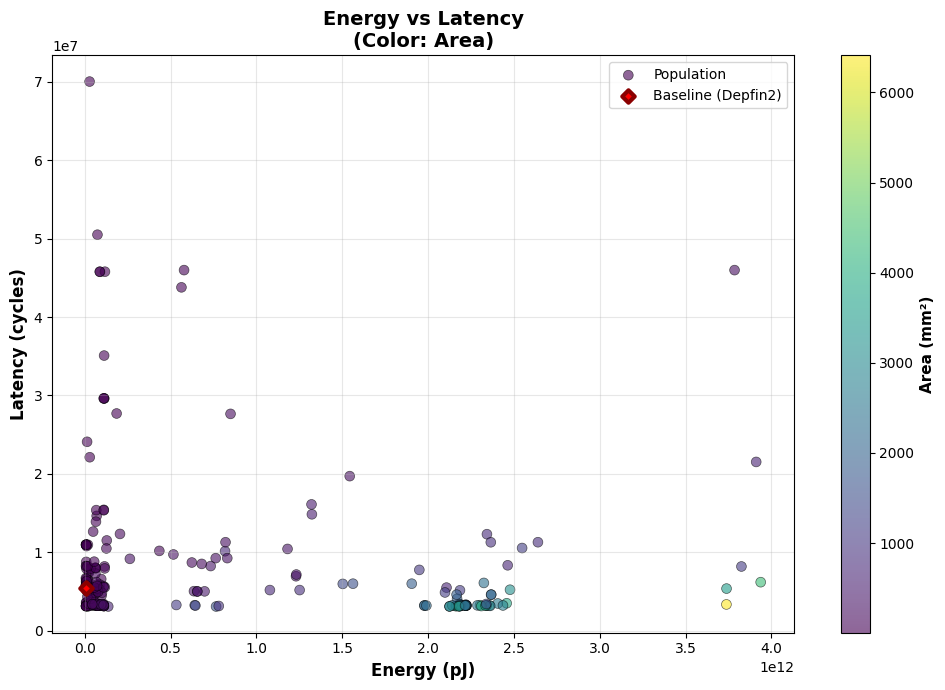

Plotted 245 valid points


In [47]:
fig, ax = plt.subplots(figsize=(10, 7))

# Normalize area for color mapping
norm = Normalize(vmin=df_valid['area'].min(), vmax=df_valid['area'].max())
cmap = viridis
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

scatter = ax.scatter(
    df_valid['energy'],
    df_valid['latency'],
    c=df_valid['area'],
    cmap=cmap,
    s=50,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5,
    label='Population'
)

# Add baseline if available
if baseline_valid:
    ax.scatter(baseline_energy, baseline_latency, c='red', s=40, marker='D', 
               edgecolors='darkred', linewidth=3, label='Baseline (Depfin2)', zorder=5)

ax.set_xlabel('Energy (pJ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (cycles)', fontsize=12, fontweight='bold')
ax.set_title('Energy vs Latency\n(Color: Area)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Area (mm²)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Plotted {len(df_valid)} valid points")

## 2. Energy vs Area (Color-coded by Latency)

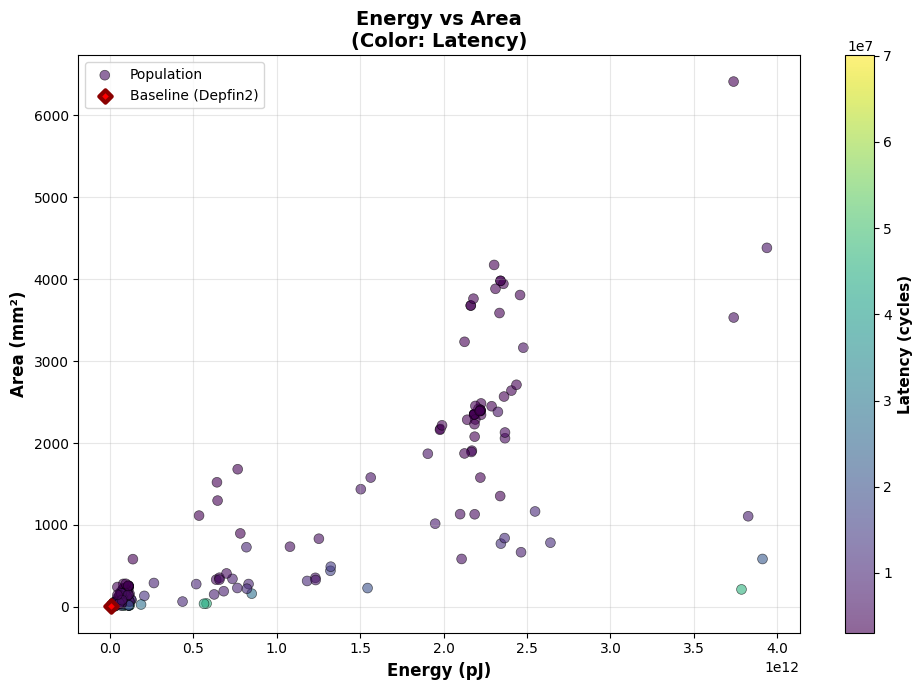

In [48]:
fig, ax = plt.subplots(figsize=(10, 7))

# Normalize latency for color mapping
norm_lat = Normalize(vmin=df_valid['latency'].min(), vmax=df_valid['latency'].max())
sm_lat = ScalarMappable(cmap=viridis, norm=norm_lat)
sm_lat.set_array([])

scatter = ax.scatter(
    df_valid['energy'],
    df_valid['area'],
    c=df_valid['latency'],
    cmap=viridis,
    s=50,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5,
    label='Population'
)

# Add baseline if available
if baseline_valid:
    ax.scatter(baseline_energy, baseline_area, c='red', s=40, marker='D', 
               edgecolors='darkred', linewidth=3, label='Baseline (Depfin2)', zorder=5)

ax.set_xlabel('Energy (pJ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Area (mm²)', fontsize=12, fontweight='bold')
ax.set_title('Energy vs Area\n(Color: Latency)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Latency (cycles)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Latency vs Area (Color-coded by Energy)

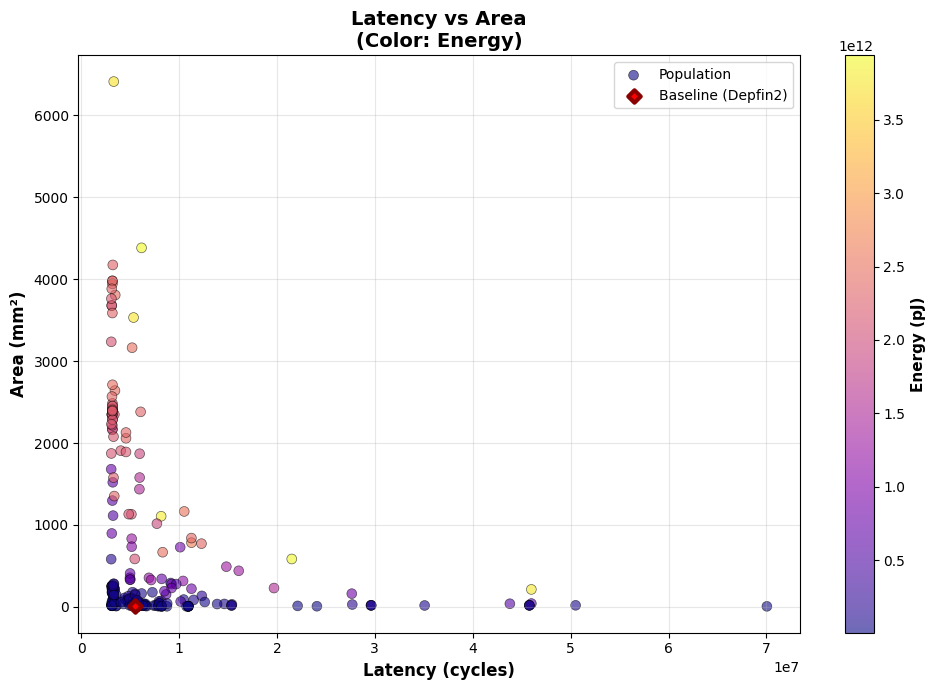

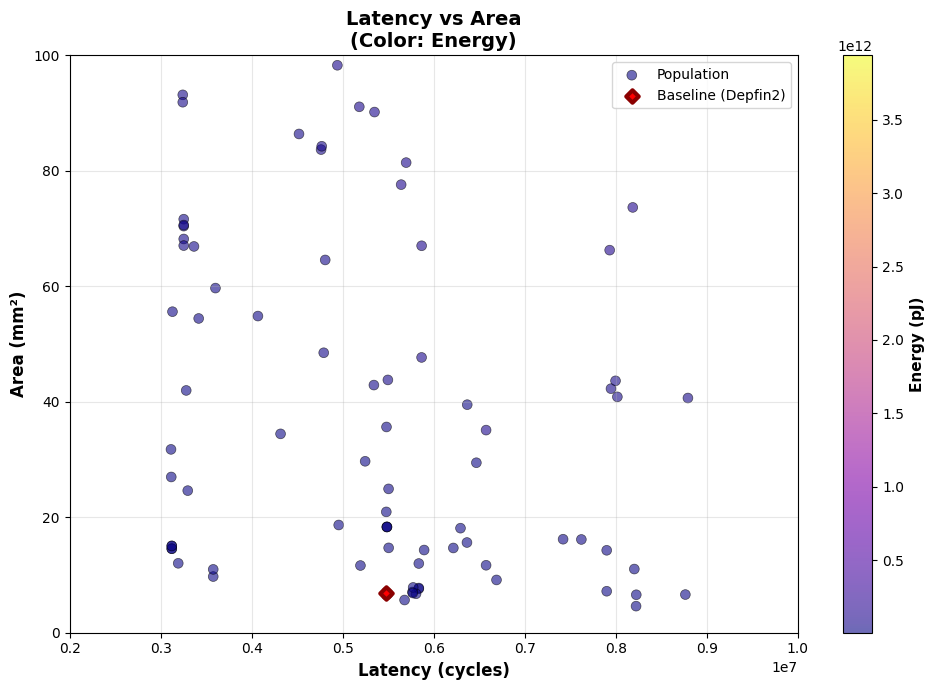

In [49]:
fig, ax = plt.subplots(figsize=(10, 7))

# Normalize energy for color mapping
norm_en = Normalize(vmin=df_valid['energy'].min(), vmax=df_valid['energy'].max())
sm_en = ScalarMappable(cmap=plasma, norm=norm_en)
sm_en.set_array([])

scatter = ax.scatter(
    df_valid['latency'],
    df_valid['area'],
    c=df_valid['energy'],
    cmap=plasma,
    s=50,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5,
    label='Population'
)

# Add baseline if available
if baseline_valid:
    ax.scatter(baseline_latency, baseline_area, c='red', s=40, marker='D', 
               edgecolors='darkred', linewidth=3, label='Baseline (Depfin2)', zorder=5)

ax.set_xlabel('Latency (cycles)', fontsize=12, fontweight='bold')
ax.set_ylabel('Area (mm²)', fontsize=12, fontweight='bold')
ax.set_title('Latency vs Area\n(Color: Energy)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy (pJ)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))

# Normalize energy for color mapping
norm_en = Normalize(vmin=df_valid['energy'].min(), vmax=df_valid['energy'].max())
sm_en = ScalarMappable(cmap=plasma, norm=norm_en)
sm_en.set_array([])

scatter = ax.scatter(
    df_valid['latency'],
    df_valid['area'],
    c=df_valid['energy'],
    cmap=plasma,
    s=50,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5,
    label='Population'
)
plt.ylim(0, 100)
plt.xlim(0.2e7, 1e7)
# Add baseline if available
if baseline_valid:
    ax.scatter(baseline_latency, baseline_area, c='red', s=40, marker='D', 
               edgecolors='darkred', linewidth=3, label='Baseline (Depfin2)', zorder=5)

ax.set_xlabel('Latency (cycles)', fontsize=12, fontweight='bold')
ax.set_ylabel('Area (mm²)', fontsize=12, fontweight='bold')
ax.set_title('Latency vs Area\n(Color: Energy)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy (pJ)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. 3D Scatter Plot (Energy, Latency, Area)

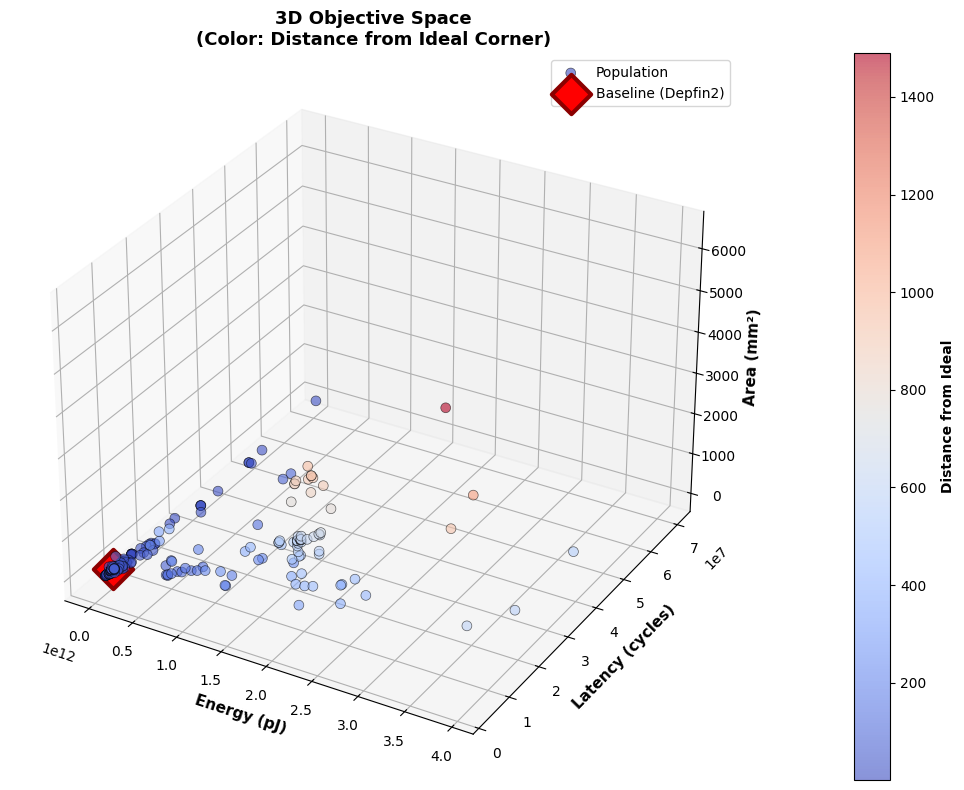

In [50]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Compute distance from ideal corner (lower is better)
ideal_energy = df_valid['energy'].min()
ideal_latency = df_valid['latency'].min()
ideal_area = df_valid['area'].min()

distance_from_ideal = np.sqrt(
    ((df_valid['energy'] - ideal_energy) / ideal_energy) ** 2 +
    ((df_valid['latency'] - ideal_latency) / ideal_latency) ** 2 +
    ((df_valid['area'] - ideal_area) / ideal_area) ** 2
)

# Plot population with distance coloring
scatter = ax.scatter(
    df_valid['energy'],
    df_valid['latency'],
    df_valid['area'],
    c=distance_from_ideal,
    cmap='coolwarm',
    s=50,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5,
    label='Population'
)

# Add baseline if available
if baseline_valid:
    baseline_distance = np.sqrt(
        ((baseline_energy - ideal_energy) / ideal_energy) ** 2 +
        ((baseline_latency - ideal_latency) / ideal_latency) ** 2 +
        ((baseline_area - ideal_area) / ideal_area) ** 2
    )
    ax.scatter(baseline_energy, baseline_latency, baseline_area, 
               c='red', s=400, marker='D', edgecolors='darkred', 
               linewidth=3, label='Baseline (Depfin2)', zorder=5)

ax.set_xlabel('Energy (pJ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Latency (cycles)', fontsize=11, fontweight='bold')
ax.set_zlabel('Area (mm²)', fontsize=11, fontweight='bold')
ax.set_title('3D Objective Space\n(Color: Distance from Ideal Corner)', fontsize=13, fontweight='bold')
ax.legend(loc='best')

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Distance from Ideal', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Pareto Front Analysis

/tmp/ipykernel_782222/484669034.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pareto_cmap = plt.cm.get_cmap("tab20", max(n_pareto, 1))


Total Pareto front entries: 13
Valid Pareto front entries: 13
Baseline on Pareto front: False


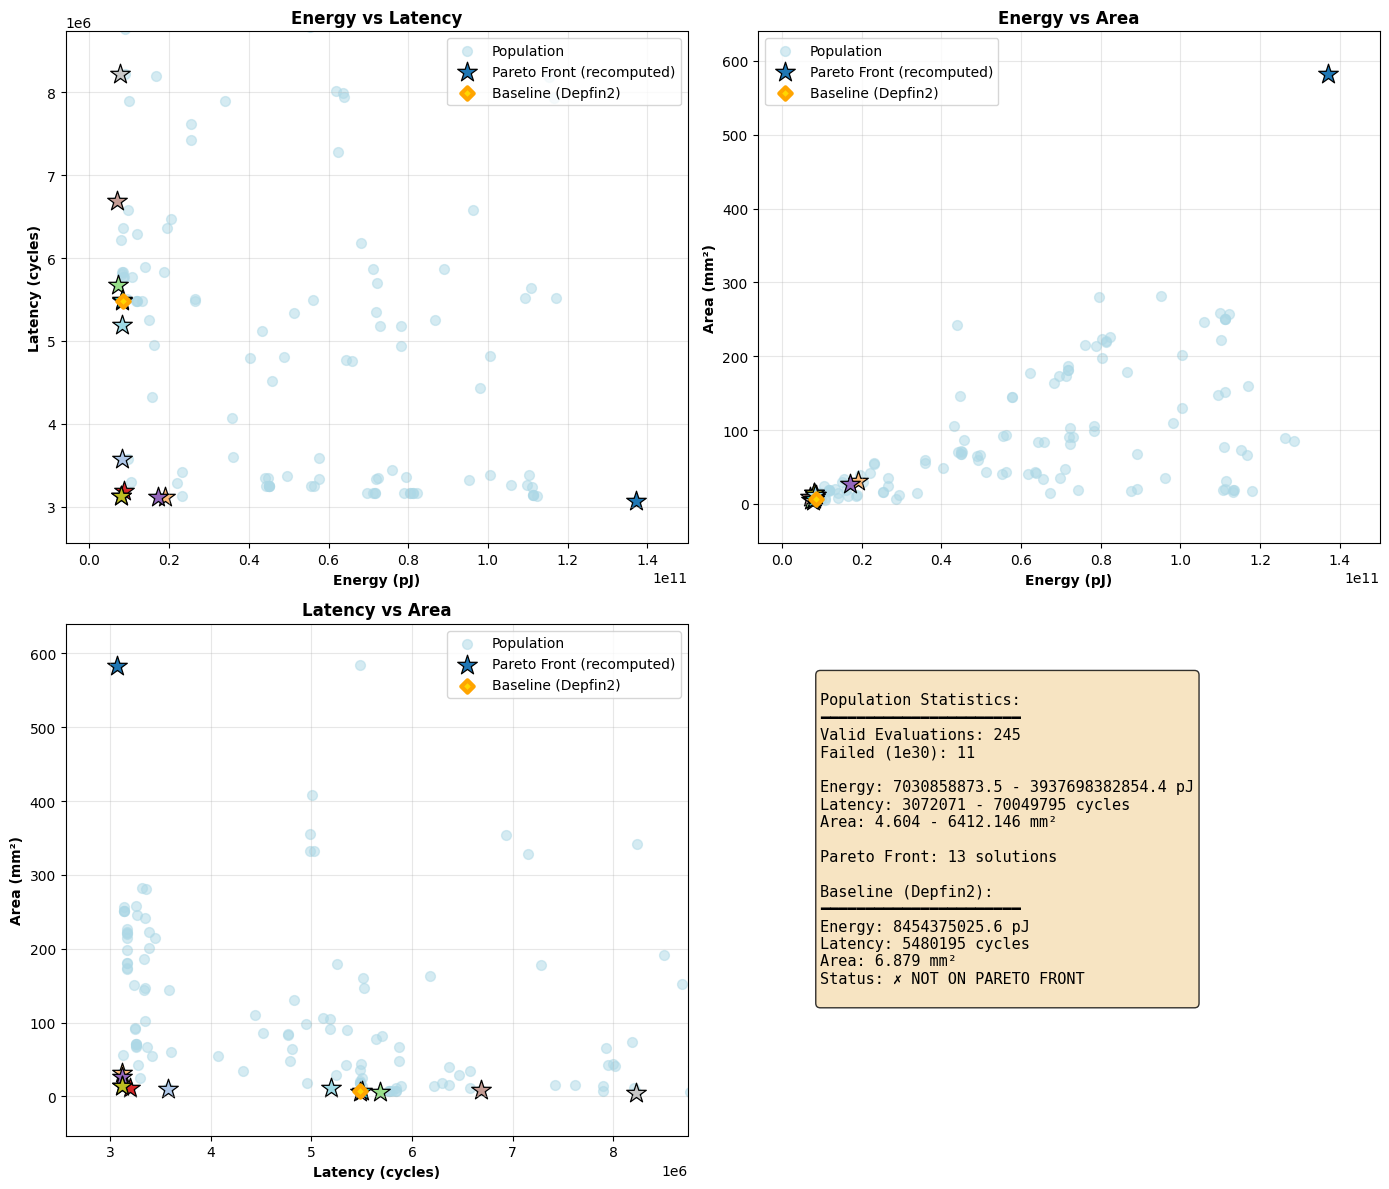

In [ ]:
# Extract Pareto front (excluding failed evaluations with 1e30)
pareto_front_all = ga_data["pareto_front"]
pareto_front = [p for p in pareto_front_all if p["energy"] < 1e20 and p["latency"] < 1e20 and p["area"] < 1e20]

pareto_energy = [p["energy"] for p in pareto_front]
pareto_latency = [p["latency"] for p in pareto_front]
pareto_area = [p["area"] for p in pareto_front]

# Unique color per Pareto point (same color identity across all subplots)
n_pareto = len(pareto_front)
pareto_cmap = plt.cm.get_cmap("tab20", max(n_pareto, 1))
pareto_colors = [pareto_cmap(i) for i in range(n_pareto)]


def limits_around_baseline(value, margin_ratio=0.50):
    value = float(value)
    pad = abs(value) * margin_ratio
    if pad <= 0:
        pad = 1.0
    return value - pad, value + pad


e_lim = limits_around_baseline(baseline_energy, margin_ratio=0.50) if baseline_valid else (min(pareto_energy), max(pareto_energy))
l_lim = limits_around_baseline(baseline_latency, margin_ratio=0.50) if baseline_valid else (min(pareto_latency), max(pareto_latency))
a_lim = limits_around_baseline(baseline_area, margin_ratio=0.50) if baseline_valid else (min(pareto_area), max(pareto_area))

# Check if baseline is on Pareto front
baseline_on_pareto = False
if baseline_valid:
    for p in pareto_front:
        if abs(p["energy"] - baseline_energy) < 1e-6 and \
           abs(p["latency"] - baseline_latency) < 1e-6 and \
           abs(p["area"] - baseline_area) < 1e-6:
            baseline_on_pareto = True
            break

print(f"Total Pareto front entries: {len(pareto_front_all)}")
print(f"Valid Pareto front entries: {len(pareto_front)}")
print(f"Baseline on Pareto front: {baseline_on_pareto}")

# Create a 2x2 subplot showing Pareto front overlaid on population
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Energy vs Latency
ax = axes[0, 0]
ax.scatter(df_valid['energy'], df_valid['latency'], c='lightblue', s=50, alpha=0.5, label='Population')
for i in range(n_pareto):
    ax.scatter(
        pareto_energy[i], pareto_latency[i],
        c=[pareto_colors[i]], s=220, marker='*',
        edgecolors='black', linewidth=0.9,
        label='Pareto Front (recomputed)' if i == 0 else None
    )
if baseline_valid:
    ax.scatter(baseline_energy, baseline_latency, c='gold', s=40, marker='D', 
               edgecolors='orange', linewidth=3, label='Baseline (Depfin2)', zorder=5)
ax.set_xlim(*e_lim)
ax.set_ylim(*l_lim)
ax.set_xlabel('Energy (pJ)', fontweight='bold')
ax.set_ylabel('Latency (cycles)', fontweight='bold')
ax.set_title('Energy vs Latency', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Energy vs Area
ax = axes[0, 1]
ax.scatter(df_valid['energy'], df_valid['area'], c='lightblue', s=50, alpha=0.5, label='Population')
for i in range(n_pareto):
    ax.scatter(
        pareto_energy[i], pareto_area[i],
        c=[pareto_colors[i]], s=220, marker='*',
        edgecolors='black', linewidth=0.9,
        label='Pareto Front (recomputed)' if i == 0 else None
    )
if baseline_valid:
    ax.scatter(baseline_energy, baseline_area, c='gold', s=40, marker='D', 
               edgecolors='orange', linewidth=3, label='Baseline (Depfin2)', zorder=5)
ax.set_xlim(*e_lim)
ax.set_ylim(*a_lim)
ax.set_xlabel('Energy (pJ)', fontweight='bold')
ax.set_ylabel('Area (mm²)', fontweight='bold')
ax.set_title('Energy vs Area', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Latency vs Area
ax = axes[1, 0]
ax.scatter(df_valid['latency'], df_valid['area'], c='lightblue', s=50, alpha=0.5, label='Population')
for i in range(n_pareto):
    ax.scatter(
        pareto_latency[i], pareto_area[i],
        c=[pareto_colors[i]], s=220, marker='*',
        edgecolors='black', linewidth=0.9,
        label='Pareto Front (recomputed)' if i == 0 else None
    )
if baseline_valid:
    ax.scatter(baseline_latency, baseline_area, c='gold', s=40, marker='D', 
               edgecolors='orange', linewidth=3, label='Baseline (Depfin2)', zorder=5)
ax.set_xlim(*l_lim)
ax.set_ylim(*a_lim)
ax.set_xlabel('Latency (cycles)', fontweight='bold')
ax.set_ylabel('Area (mm²)', fontweight='bold')
ax.set_title('Latency vs Area', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Statistics
ax = axes[1, 1]
ax.axis('off')
baseline_status = "✓ ON PARETO FRONT" if baseline_on_pareto else "✗ NOT ON PARETO FRONT"
stats_text = f"""
Population Statistics:
━━━━━━━━━━━━━━━━━━━━━━
Valid Evaluations: {len(df_valid)}
Failed (1e30): {len(df_results) - len(df_valid)}

Energy: {df_valid['energy'].min():.1f} - {df_valid['energy'].max():.1f} pJ
Latency: {df_valid['latency'].min():.0f} - {df_valid['latency'].max():.0f} cycles
Area: {df_valid['area'].min():.3f} - {df_valid['area'].max():.3f} mm²

Pareto Front: {len(pareto_front)} solutions

Baseline (Depfin2):
━━━━━━━━━━━━━━━━━━━━━━
Energy: {baseline_energy:.1f} pJ
Latency: {baseline_latency:.0f} cycles
Area: {baseline_area:.3f} mm²
Status: {baseline_status}
"""
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

/tmp/ipykernel_782222/1950431937.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pareto_cmap = plt.cm.get_cmap("Paired", max(n_pareto, 1))


Total Pareto front entries: 13
Valid Pareto front entries: 13
Baseline on Pareto front: False


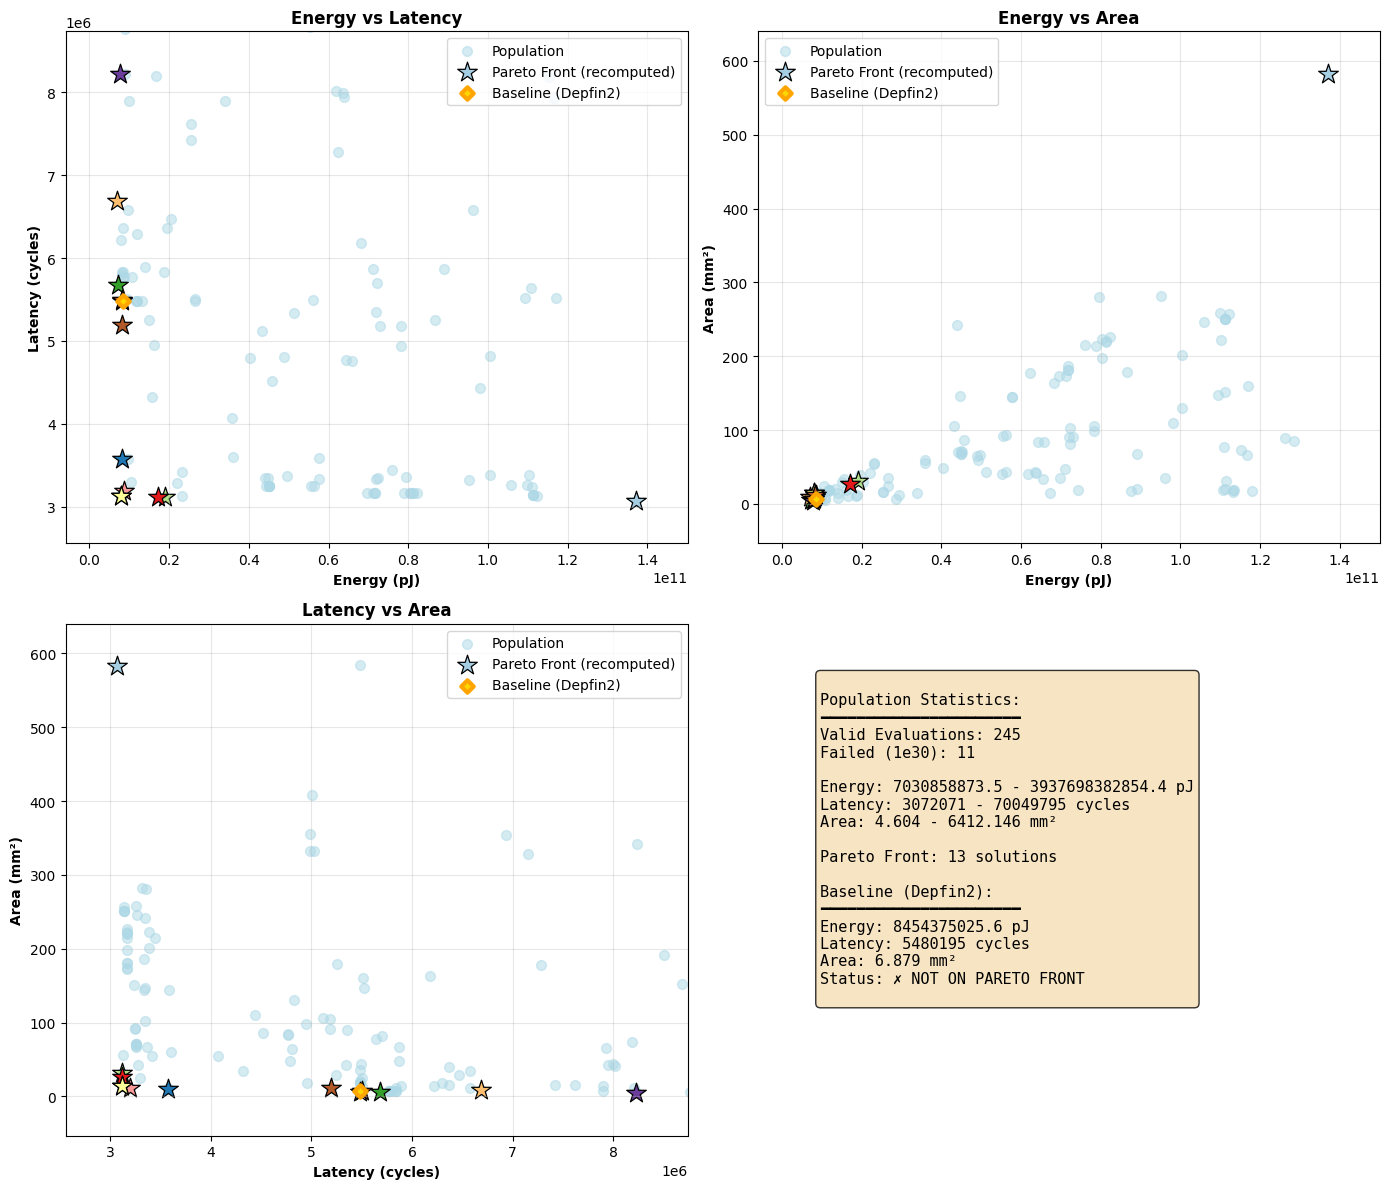

In [ ]:
# Extract Pareto front (excluding failed evaluations with 1e30)
pareto_front_all = ga_data["pareto_front"]
pareto_front = [p for p in pareto_front_all if p["energy"] < 1e20 and p["latency"] < 1e20 and p["area"] < 1e20]

pareto_energy = [p["energy"] for p in pareto_front]
pareto_latency = [p["latency"] for p in pareto_front]
pareto_area = [p["area"] for p in pareto_front]

# Unique color per Pareto point (same color identity across all subplots)
n_pareto = len(pareto_front)
pareto_cmap = plt.cm.get_cmap("Paired", max(n_pareto, 1))
pareto_colors = [pareto_cmap(i) for i in range(n_pareto)]


def limits_around_baseline(value, margin_ratio=0.50):
    value = float(value)
    pad = abs(value) * margin_ratio
    if pad <= 0:
        pad = 1.0
    return value - pad, value + pad


e_lim = limits_around_baseline(baseline_energy, margin_ratio=0.50) if baseline_valid else (min(pareto_energy), max(pareto_energy))
l_lim = limits_around_baseline(baseline_latency, margin_ratio=0.50) if baseline_valid else (min(pareto_latency), max(pareto_latency))
a_lim = limits_around_baseline(baseline_area, margin_ratio=0.50) if baseline_valid else (min(pareto_area), max(pareto_area))

# Check if baseline is on Pareto front
baseline_on_pareto = False
if baseline_valid:
    for p in pareto_front:
        if abs(p["energy"] - baseline_energy) < 1e-6 and \
           abs(p["latency"] - baseline_latency) < 1e-6 and \
           abs(p["area"] - baseline_area) < 1e-6:
            baseline_on_pareto = True
            break

print(f"Total Pareto front entries: {len(pareto_front_all)}")
print(f"Valid Pareto front entries: {len(pareto_front)}")
print(f"Baseline on Pareto front: {baseline_on_pareto}")

# Create a 2x2 subplot showing Pareto front overlaid on population
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Energy vs Latency
ax = axes[0, 0]
ax.scatter(df_valid['energy'], df_valid['latency'], c='lightblue', s=50, alpha=0.5, label='Population')
for i in range(n_pareto):
    ax.scatter(
        pareto_energy[i], pareto_latency[i],
        c=[pareto_colors[i]], s=220, marker='*',
        edgecolors='black', linewidth=0.9,
        label='Pareto Front (recomputed)' if i == 0 else None
    )
if baseline_valid:
    ax.scatter(baseline_energy, baseline_latency, c='gold', s=40, marker='D', 
               edgecolors='orange', linewidth=3, label='Baseline (Depfin2)', zorder=5)

ax.set_xlim(*e_lim)
ax.set_ylim(*l_lim)
ax.set_xlabel('Energy (pJ)', fontweight='bold')
ax.set_ylabel('Latency (cycles)', fontweight='bold')
ax.set_title('Energy vs Latency', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Energy vs Area
ax = axes[0, 1]
ax.scatter(df_valid['energy'], df_valid['area'], c='lightblue', s=50, alpha=0.5, label='Population')
for i in range(n_pareto):
    ax.scatter(
        pareto_energy[i], pareto_area[i],
        c=[pareto_colors[i]], s=220, marker='*',
        edgecolors='black', linewidth=0.9,
        label='Pareto Front (recomputed)' if i == 0 else None
    )
if baseline_valid:
    ax.scatter(baseline_energy, baseline_area, c='gold', s=40, marker='D', 
               edgecolors='orange', linewidth=3, label='Baseline (Depfin2)', zorder=5)
ax.set_xlim(*e_lim)
ax.set_ylim(*a_lim)
ax.set_xlabel('Energy (pJ)', fontweight='bold')
ax.set_ylabel('Area (mm²)', fontweight='bold')
ax.set_title('Energy vs Area', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Latency vs Area
ax = axes[1, 0]
ax.scatter(df_valid['latency'], df_valid['area'], c='lightblue', s=50, alpha=0.5, label='Population')
for i in range(n_pareto):
    ax.scatter(
        pareto_latency[i], pareto_area[i],
        c=[pareto_colors[i]], s=220, marker='*',
        edgecolors='black', linewidth=0.9,
        label='Pareto Front (recomputed)' if i == 0 else None
    )
if baseline_valid:
    ax.scatter(baseline_latency, baseline_area, c='gold', s=40, marker='D', 
               edgecolors='orange', linewidth=3, label='Baseline (Depfin2)', zorder=5)
ax.set_xlim(*l_lim)
ax.set_ylim(*a_lim)
ax.set_xlabel('Latency (cycles)', fontweight='bold')
ax.set_ylabel('Area (mm²)', fontweight='bold')
ax.set_title('Latency vs Area', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Statistics
ax = axes[1, 1]
ax.axis('off')
baseline_status = "✓ ON PARETO FRONT" if baseline_on_pareto else "✗ NOT ON PARETO FRONT"
stats_text = f"""
Population Statistics:
━━━━━━━━━━━━━━━━━━━━━━
Valid Evaluations: {len(df_valid)}
Failed (1e30): {len(df_results) - len(df_valid)}

Energy: {df_valid['energy'].min():.1f} - {df_valid['energy'].max():.1f} pJ
Latency: {df_valid['latency'].min():.0f} - {df_valid['latency'].max():.0f} cycles
Area: {df_valid['area'].min():.3f} - {df_valid['area'].max():.3f} mm²

Pareto Front: {len(pareto_front)} solutions

Baseline (Depfin2):
━━━━━━━━━━━━━━━━━━━━━━
Energy: {baseline_energy:.1f} pJ
Latency: {baseline_latency:.0f} cycles
Area: {baseline_area:.3f} mm²
Status: {baseline_status}
"""
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## 6. Metric Distributions

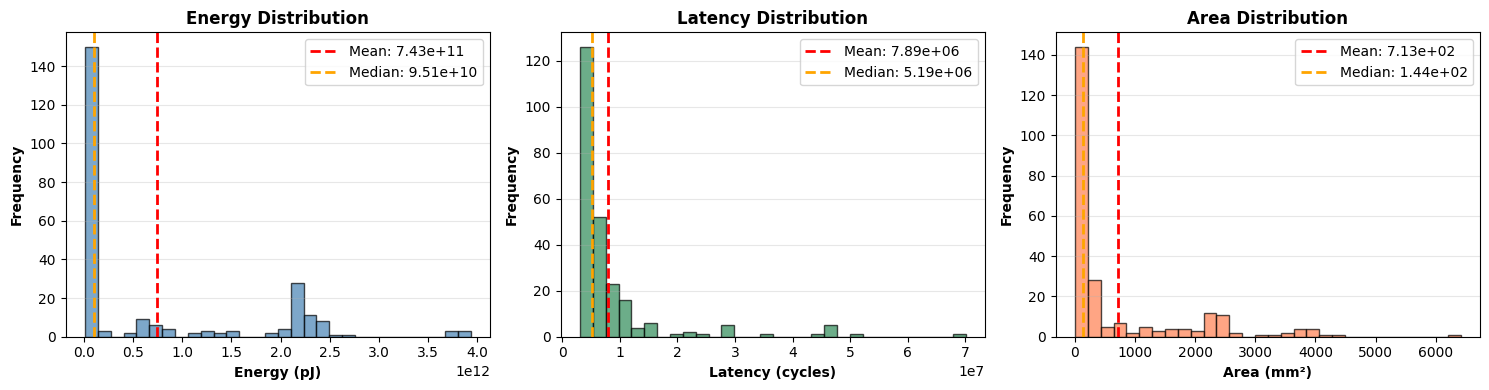

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Energy distribution
ax = axes[0]
ax.hist(df_valid['energy'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(df_valid['energy'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_valid["energy"].mean():.2e}')
ax.axvline(df_valid['energy'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df_valid["energy"].median():.2e}')
ax.set_xlabel('Energy (pJ)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Energy Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Latency distribution
ax = axes[1]
ax.hist(df_valid['latency'], bins=30, color='seagreen', alpha=0.7, edgecolor='black')
ax.axvline(df_valid['latency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_valid["latency"].mean():.2e}')
ax.axvline(df_valid['latency'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df_valid["latency"].median():.2e}')
ax.set_xlabel('Latency (cycles)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Latency Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Area distribution
ax = axes[2]
ax.hist(df_valid['area'], bins=30, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(df_valid['area'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_valid["area"].mean():.2e}')
ax.axvline(df_valid['area'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df_valid["area"].median():.2e}')
ax.set_xlabel('Area (mm²)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Area Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Pareto Front Details Table

In [54]:
pareto_df = pd.DataFrame({
    "Energy (pJ)": [p["energy"] for p in pareto_front],
    "Latency (cycles)": [p["latency"] for p in pareto_front],
    "Area (mm²)": [p["area"] for p in pareto_front],
    "D1": [p["params"]["d1_size"] for p in pareto_front],
    "D2": [p["params"]["d2_size"] for p in pareto_front],
    "RF_1B_I (B)": [p["params"]["rf_1b_i_size"] for p in pareto_front],
    "RF_1B_W (B)": [p["params"]["rf_1b_w_size"] for p in pareto_front],
    "RF_4B (B)": [p["params"]["rf_4b_size"] for p in pareto_front],
    "L1_W (B)": [p["params"]["l1_w_size"] for p in pareto_front],
    "L1_Act (B)": [p["params"]["l1_act_size"] for p in pareto_front],
})

print("Pareto Front Designs (Valid):")
print("=" * 150)
if len(pareto_df) > 0:
    print(pareto_df.to_string(index=False))
else:
    print("No valid Pareto front points found")
print("=" * 150)

Pareto Front Designs (Valid):
 Energy (pJ)  Latency (cycles)  Area (mm²)  D1  D2  RF_1B_I (B)  RF_1B_W (B)  RF_4B (B)  L1_W (B)  L1_Act (B)
1.370986e+11         3072071.0  582.166264 233  58          480          152        128   6391256     3175944
8.291890e+09         3577034.0    9.728148 226  16            8            8         16   4179248     9098888
1.904478e+10         3113148.0   31.753693 231  33            8           16         72   9160136     3420000
7.268952e+09         5679015.0    5.664795 125  21            8            8         16   4194304     1567184
8.554963e+09         3192658.0   12.024495 226  20            8            8         16   6524912     8730808
1.713292e+10         3116025.0   26.974224 229  31           16           16         56   4143264     8494024
7.968178e+09         3121788.0   14.546996 226  32            8            8         16   4184344     8440392
7.030859e+09         6688935.0    9.142250 237  21            8            8         16   